In [24]:
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
import tensorboard as tb
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('../dataset/Iisingintie_Acc1_m802_RDMC_2026-05-06_125211.txt', sep='\t')

df.head()

,Num,Timer(ms),Loc(m),Speed (m/s),East(m),North(m),CElev(m),Roll(deg),Pitch(deg),Yaw(deg),...,AccY,AccZ,GyrX,GyrY,GyrZ,RBCSV_80(cf),RBCSV_60(cf),posneg,vaikeus,muu
0,1,46338791,"3760,066","0,019","426296,309","7414096,396","108,743","2,1453","-2,2657","4,656",...,"0,37525","9,83232","-0,00211","0,00381","-0,00527","2,75313","2,78428",0,0,0
1,2,"46338793,5","3760,066","0,019","426296,309","7414096,396","108,743","2,1458","-2,2654","4,6557",...,"0,36549","9,83108","-0,00133","0,00337","-0,00678","2,75313","2,78428",0,0,0
2,3,"46338788,5","3760,066","0,019","426296,309","7414096,396","108,742","2,1449","-2,2661","4,656",...,"0,37656","9,80323","-0,00655","0,00658","0,00035","2,75313","2,78428",0,0,0
3,4,46338796,"3760,066","0,019","426296,309","7414096,396","108,743","2,1459","-2,2655","4,6557",...,"0,34235","9,84292","-0,00466",8E-05,"-0,00434","2,75313","2,78428",0,0,0
4,5,46338786,"3760,066","0,019","426296,309","7414096,396","108,742","2,1451","-2,2668","4,6553",...,"0,35458","9,81651","-0,00426","-0,00212","-0,00315","2,75313","2,78428",0,0,0


In [26]:
df = df.drop(columns=['Num'])

In [27]:
df.columns

Index(['Timer(ms)', 'Loc(m)', 'Speed (m/s)', 'East(m)', 'North(m)', 'CElev(m)',
       'Roll(deg)', 'Pitch(deg)', 'Yaw(deg)', 'AccX', 'AccY', 'AccZ', 'GyrX',
       'GyrY', 'GyrZ', 'RBCSV_80(cf)', 'RBCSV_60(cf)', 'posneg', 'vaikeus',
       'muu'],
      dtype='str')

In [28]:
for column in df.columns:
    df[column] = pd.to_numeric(df[column].astype(str).str.replace(",", ".", regex=False))
    print(f"{column} done!")

Timer(ms) done!
Loc(m) done!
Speed (m/s) done!
East(m) done!
North(m) done!
CElev(m) done!
Roll(deg) done!
Pitch(deg) done!
Yaw(deg) done!
AccX done!
AccY done!
AccZ done!
GyrX done!
GyrY done!
GyrZ done!
RBCSV_80(cf) done!
RBCSV_60(cf) done!
posneg done!
vaikeus done!
muu done!


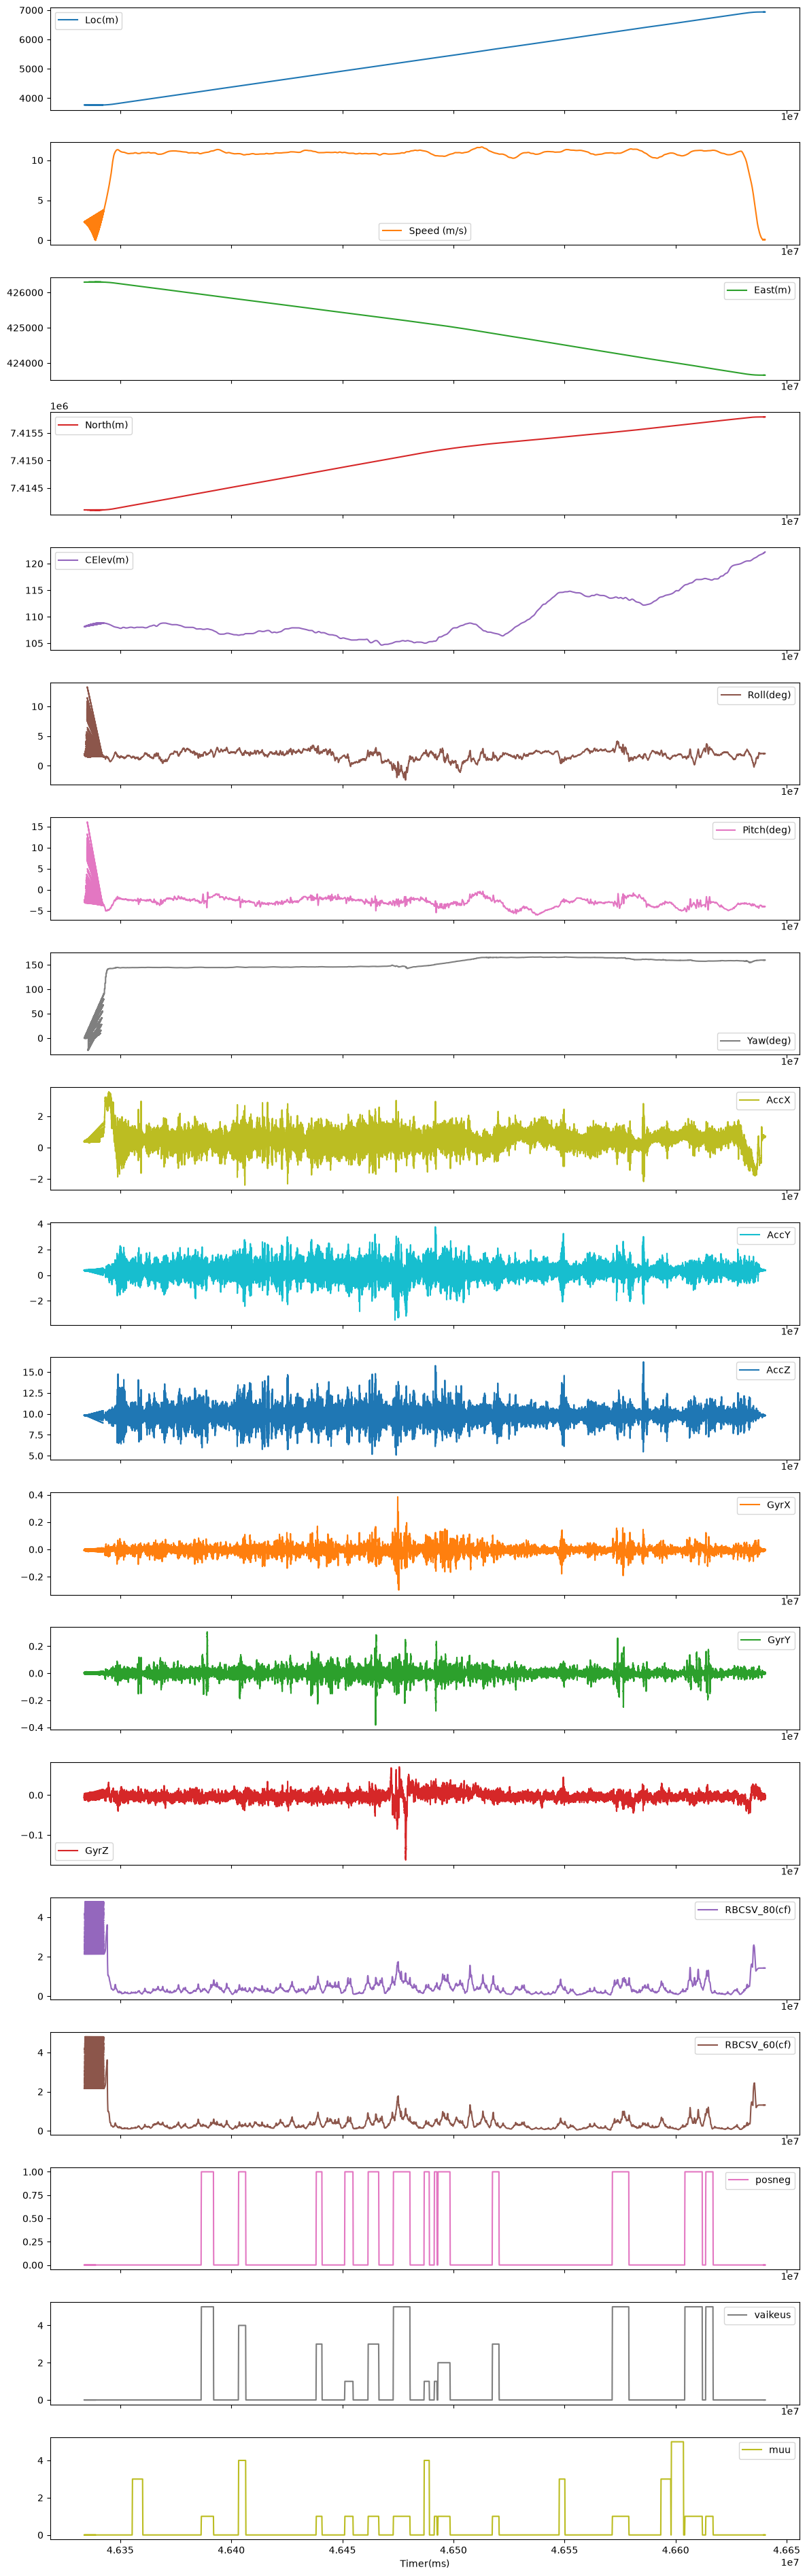

In [29]:
df.plot(x="Timer(ms)", subplots=True, figsize=(12, 2 * (len(df.columns) - 1)), sharex=True)
plt.tight_layout()
plt.show()

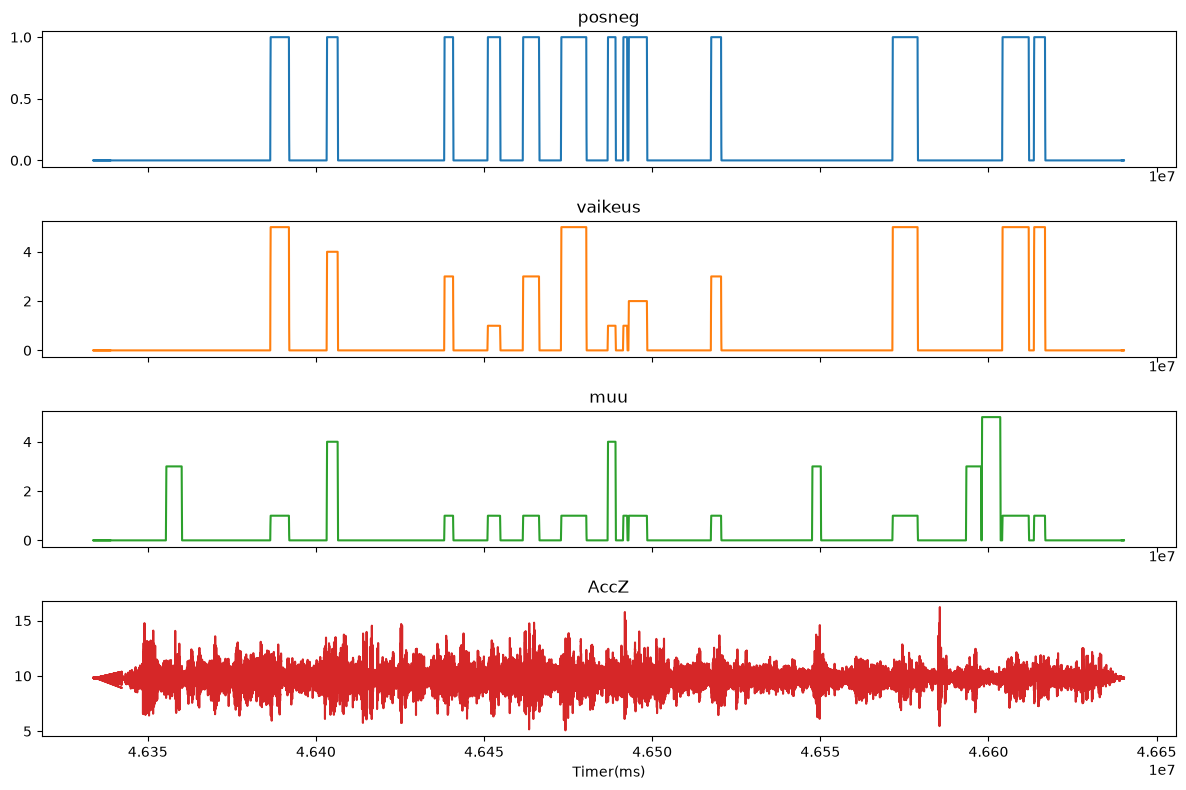

In [30]:
cols = ["posneg", "vaikeus", "muu", "AccZ"]

axes = df.plot(
    x="Timer(ms)",
    y=cols,
    subplots=True,
    figsize=(12, 2 * len(cols)),
    sharex=True,
    legend=False,
    title=cols,
)
plt.tight_layout()
plt.savefig("signalsACCZ1.png", dpi=150)
plt.show()

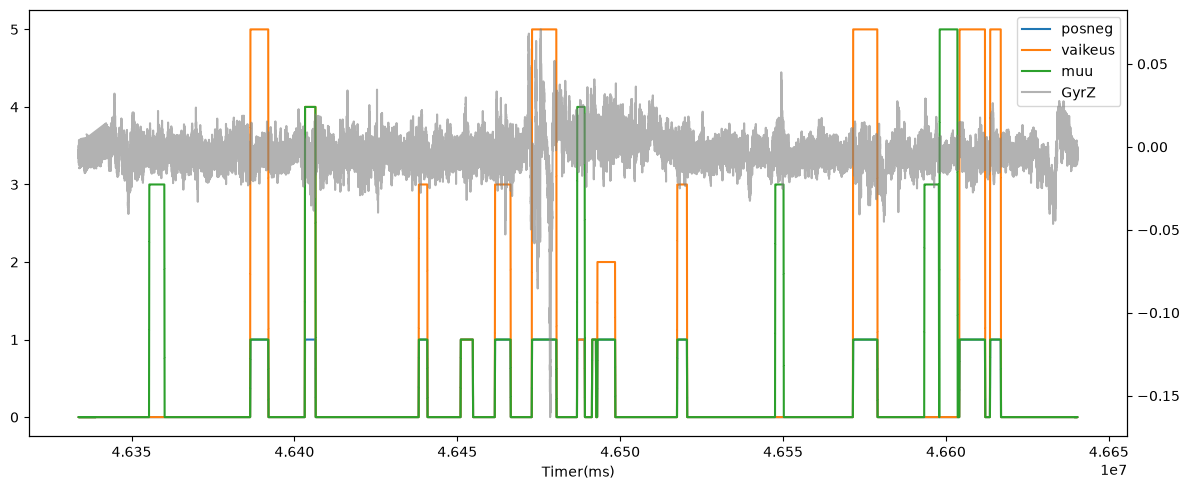

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

for c in ["posneg", "vaikeus", "muu"]:
    ax.plot(df["Timer(ms)"], df[c], label=c, drawstyle="steps-post")

ax2 = ax.twinx()
ax2.plot(df["Timer(ms)"], df["GyrZ"], color="gray", alpha=0.6, label="GyrZ")

ax.set_xlabel("Timer(ms)")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")

plt.tight_layout()
plt.savefig("signalsGYSZ1.png", dpi=150)
plt.show()